In [36]:
import pandas as pd

In [37]:
df = pd.read_csv("Housing.csv")

## Load Dataset

In [38]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [39]:
df["furnishingstatus"].unique()

array(['furnished', 'semi-furnished', 'unfurnished'], dtype=object)

## Label Encoding

In [40]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

le = LabelEncoder()

df["mainroad"] = le.fit_transform(df["mainroad"])
df["guestroom"] = le.fit_transform(df["guestroom"])
df["basement"] = le.fit_transform(df["basement"])
df["hotwaterheating"] = le.fit_transform(df["hotwaterheating"])
df["airconditioning"] = le.fit_transform(df["airconditioning"])
df["prefarea"] = le.fit_transform(df["prefarea"])

In [41]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


## OneHote Encoding

In [42]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)

# Convert to 2D
encoded = ohe.fit_transform(df[["furnishingstatus"]])

# Step 2: Create DataFrame with proper column names
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(["furnishingstatus"]),
    index=df.index   # ✅ important to align rows
)

# Step 3: Combine with original df
df = pd.concat([df, encoded_df], axis=1)


In [43]:
df= df.drop("furnishingstatus",axis = 1)

In [44]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1.0,0.0,0.0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1.0,0.0,0.0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0.0,1.0,0.0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1.0,0.0,0.0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1.0,0.0,0.0


In [45]:
df.shape

(545, 15)

In [46]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus_furnished',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')

## EDA (Expolatory Data Analyisis)

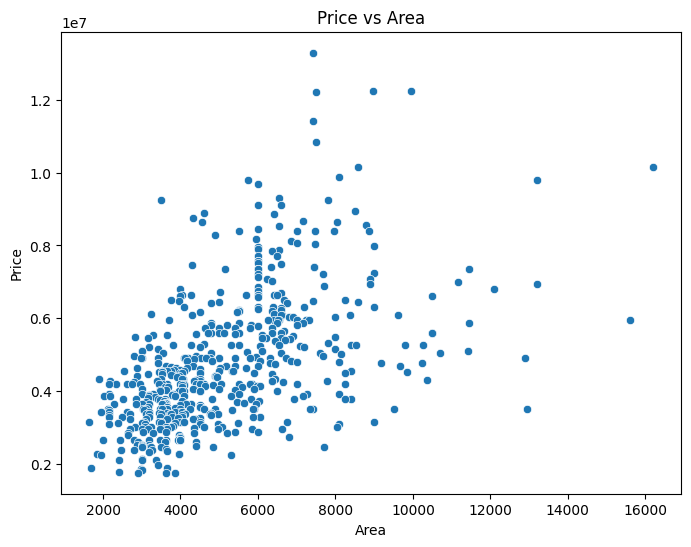

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(x=df["area"], y=df["price"])

plt.title("Price vs Area")
plt.xlabel("Area")
plt.ylabel("Price")

plt.show()

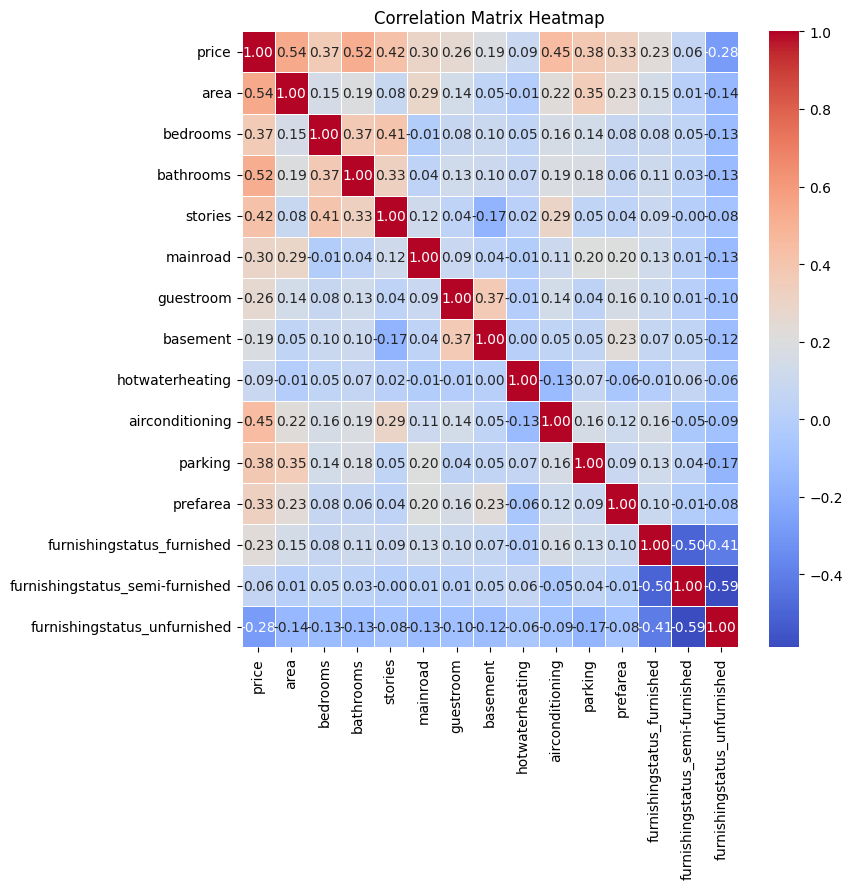

In [48]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,8))

sns.heatmap(
    corr,
    annot=True,        # show values
    cmap="coolwarm",   # color style
    fmt=".2f",         # 2 decimal places
    linewidths=0.5
)

plt.title("Correlation Matrix Heatmap")
plt.show()

## Train Test Split

In [49]:
from sklearn.model_selection import train_test_split

X = df.drop("price", axis = 1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size = 0.2, random_state = 42
)


In [69]:
print(f"Orignal_data = {df.shape} | training_data = {X_train.shape} | testing_data ={X_test.shape}" )

Orignal_data = (545, 15) | training_data = (436, 14) | testing_data =(109, 14)


## Scaling Data

In [70]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_trained_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [71]:
X_test_scaled

array([[ 0.33875048,  1.39405543,  1.53917323, ..., -0.58441292,
        -0.870669  ,  1.47732249],
       [ 0.61125674,  0.05527092,  1.53917323, ...,  1.71111891,
        -0.870669  , -0.67690027],
       [-0.5060189 , -1.28351359, -0.5579503 , ..., -0.58441292,
         1.14854209, -0.67690027],
       ...,
       [ 0.38416819,  1.39405543,  1.53917323, ..., -0.58441292,
         1.14854209, -0.67690027],
       [ 0.38416819,  0.05527092,  1.53917323, ..., -0.58441292,
         1.14854209, -0.67690027],
       [ 0.4295859 ,  0.05527092,  1.53917323, ...,  1.71111891,
        -0.870669  , -0.67690027]])

# Algorithms for Prediction

## Linear Regression

In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
lr = LinearRegression()

lr.fit(X_trained_scaled,y_train)
y_pred_scaled = lr.predict(X_test_scaled)
y_pred= lr.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_scaled)
mse = mean_squared_error(y_test, y_pred_scaled)
r2 = r2_score(y_test, y_pred_scaled)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

MAE: 970043.40
MSE: 1754318687330.67
R2 Score: 0.65


In [73]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_scaled
})

# Format Predicted column to normal numbers (no scientific notation)
comparison_df["Predicted"] = comparison_df["Predicted"].apply(lambda x: f"{x:,.0f}")
comparison_df["Actual"] = comparison_df["Actual"].apply(lambda x: f"{x:,.0f}")

# Show first 10 rows
comparison_df.head(10)

,Actual,Predicted
316,"4,060,000","5,164,654"
77,"6,650,000","7,224,722"
360,"3,710,000","3,109,863"
90,"6,440,000","4,612,075"
493,"2,800,000","3,294,646"
209,"4,900,000","3,532,275"
176,"5,250,000","5,611,775"
249,"4,543,000","6,368,146"
516,"2,450,000","2,722,857"
426,"3,353,000","2,629,406"


## RidgeCV

In [75]:
from sklearn.linear_model import RidgeCV

alphas = [0.1,0.2,0.45,0.5,0.6]
model = RidgeCV(
    alphas,
    cv = 5,
    scoring = "r2"
)
model.fit(X_trained_scaled,y_train)
y_pred_scaled = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_scaled)
mse = mean_squared_error(y_test, y_pred_scaled)
r2 = r2_score(y_test, y_pred_scaled)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

MAE: 969983.01
MSE: 1754684903101.62
R2 Score: 0.65


## LassoCV

In [80]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define LassoCV model
lasso = LassoCV(alphas=[0.01,0.1,0.5,1.0], cv=5, random_state=42)

# Fit model
lasso.fit(X_trained_scaled, y_train)

# Predict
y_pred_lasso = lasso.predict(X_test_scaled)

# Evaluate
mae = mean_absolute_error(y_test, y_pred_lasso)
mse = mean_squared_error(y_test, y_pred_lasso)
r2 = r2_score(y_test, y_pred_lasso)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

MAE: 970043.90
MSE: 1754320649501.43
R2 Score: 0.65


##  ElasticNet

In [84]:
from sklearn.linear_model import ElasticNet

# Define ElasticNet model
model = ElasticNet(alpha=1.0, l1_ratio=0.6, random_state=42)

# Fit model
model.fit(X_trained_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

MAE: 994542.15
MSE: 1942766790600.17
R2 Score: 0.62


## DecisionTreeRegressor

In [103]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# If you have original feature names from your DataFrame
feature_names = X_train.columns.tolist()  # replace X_train with your original DataFrame

# Define the model
clf = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=2,
    min_samples_leaf=2,
    random_state=42
)

# Fit the model on training data
clf.fit(X_trained_scaled, y_train)

# Predict on test data
y_pred = clf.predict(X_test_scaled)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")


MAE: 1264452.84
MSE: 2954939240916.11
R2 Score: 0.42


## Random Forest Regressor

In [105]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_trained_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

print("Random Forest Regressor")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_rf):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_rf):.2f}")

Random Forest Regressor
MAE: 1032363.35
MSE: 1986595130346.87
R2 Score: 0.61


### Gradient Boosting Regressor

In [107]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
gb.fit(X_trained_scaled, y_train)

y_pred_gb = gb.predict(X_test_scaled)

print("Gradient Boosting Regressor")
print(f"MAE: {mean_absolute_error(y_test, y_pred_gb):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_gb):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_gb):.2f}")


Gradient Boosting Regressor
MAE: 1027842.41
MSE: 1965712056546.77
R2 Score: 0.61


In [110]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.


## XGBoost Regressor

In [111]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
xgb.fit(X_trained_scaled, y_train)

y_pred_xgb = xgb.predict(X_test_scaled)

print("XGBoost Regressor")
print(f"MAE: {mean_absolute_error(y_test, y_pred_xgb):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_xgb):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_xgb):.2f}")


XGBoost Regressor
MAE: 1008435.44
MSE: 1873169350656.00
R2 Score: 0.63


## Support Vector Regressor (SVR)

In [120]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

param_grid = {
    'C': [1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1],
    'epsilon': [0.1, 0.5, 1]
}

grid = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=3, scoring='r2')
grid.fit(X_trained_scaled, y_train)

print("Best parameters:", grid.best_params_)
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
print("SVR ")
print(f"MAE: {mean_absolute_error(y_test, y_pred_knn):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_knn):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_knn):.2f}")

Best parameters: {'C': 100, 'epsilon': 0.1, 'gamma': 'scale'}
SVR 
MAE: 1015443.12
MSE: 1982043773943.12
R2 Score: 0.61


## K-Nearest Neighbors Regressor

In [117]:
from sklearn.neighbors import KNeighborsRegressor

# KNN Regressor
knn = KNeighborsRegressor(n_neighbors=5)  # try changing n_neighbors
knn.fit(X_trained_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("K-Nearest Neighbors Regressor")
print(f"MAE: {mean_absolute_error(y_test, y_pred_knn):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_knn):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_knn):.2f}")

K-Nearest Neighbors Regressor
MAE: 1015443.12
MSE: 1982043773943.12
R2 Score: 0.61


## Best Model -- XGBoost Regressor